In [1]:
import anndata
import pandas as pd
import scimap as sm
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import numpy as np
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)

Running SCIMAP  2.1.3


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



This script performs NEP analysis on the MI dataset with COZI using the github scimap fork https://github.com/chiarasch/scimap/

In [2]:
path_to_csv = './../../../../../../MI_heart_paper/data/cell_table_final.csv'
obs = pd.read_csv(path_to_csv)
output_path = './../../../../Comparison/20250218_results_MI/MI_COZI_normalized_knn15_finalsub.csv'
NEP_method = "COZI"
label_list = ('COZI_rad50','COZI_knn15', 'COZI_knn30')

In [3]:
# exclude the specified cell types in obs
ignore_cell_types = ['exclude']
obs = obs[~obs['final_cell_type'].isin(ignore_cell_types)]

In [4]:
#create anndata object
# add marker files to it, as SpatialLDA needs them
obs['D'] = np.random.randint(1, 101, size=len(obs))
obs['E'] = np.random.randint(1, 101, size=len(obs))

# Ensure obs has a string-based index
obs.index = obs.index.astype(str)  # Convert index to string


# Load dataframe into anndata object
# the data matrix 
X = obs[['D', 'E']]
X = X.values
adata = anndata.AnnData(X)
adata.obs = obs
adata

AnnData object with n_obs × n_vars = 563180 × 2
    obs: 'fov', 'label', 'cell_size', 'X_centroid', 'Y_centroid', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'cell_meta_cluster', 'timepoint', 'region', 'region_name', 'refined_cell_type', 'final_cell_type', 'endocardial_annotation', 'exclude_annotation', 'artefact', 'distance_from_lumen', 'lumen_bin', 'size_filter', 'D', 'E'

In [7]:
NEP_method = 'COZI'
label = 'COZI_rad50'

In [6]:
adata.obs['region_name'].value_counts()

region_name
other_cardiac_tissue         355444
infarct_core                  94551
border_zone                   80395
endocardial_region            14698
epicardial_region             11592
remote_endocardial_region      6500
Name: count, dtype: int64

In [ ]:
# rad50
# Define the spatial interaction analysis
spatial_params = {
    'adata': adata,
    'x_coordinate': 'X_centroid',
    'y_coordinate': 'Y_centroid',
    'phenotype': 'final_cell_type',
    'method': 'radius',
    'radius': 50,
    'permutation': 300,
    'imageid': 'fov',
    'min_celltype_count': 20,
    'subset': None,
    'pval_method': 'zscore',
    'verbose': True,
    'label': label
}

# Conditionally include normalization based on method
if NEP_method == 'SEA':
    spatial_params['normalization'] = 'total'  # Example of adding normalization for 'knn'
if NEP_method == 'COZI':
    spatial_params['normalization'] = 'conditional'  # Example of adding normalization for 'knn'

# Run spatial interaction analysis with the conditional parameter
spatial = sm.tl.spatial_interaction(**spatial_params)


Processing Image: ['24h_86']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['24h_83']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_12']
Retaining 10 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_97']
Retaining 11 phenotypes with ≥ 20 cells
Identifying neighbours within 50 pixels of e

In [24]:
# knn15
label = 'COZI_knn15'
# Define the spatial interaction analysis
spatial_params = {
    'adata': adata,
    'x_coordinate': 'X_centroid',
    'y_coordinate': 'Y_centroid',
    'phenotype': 'final_cell_type',
    'method': 'knn',
    'knn': 15,
    'permutation': 300,
    'imageid': 'fov',
    'min_celltype_count': 20,
    'subset': None,
    'pval_method': 'zscore',
    'verbose': True,
    'label': label
}

# Conditionally include normalization based on method
if NEP_method == 'SEA':
    spatial_params['normalization'] = 'total'  # Example of adding normalization for 'knn'
if NEP_method == 'COZI':
    spatial_params['normalization'] = 'conditional'  # Example of adding normalization for 'knn'

# Run spatial interaction analysis with the conditional parameter
spatial = sm.tl.spatial_interaction(**spatial_params)

Processing Image: ['24h_86']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 15 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['24h_83']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 15 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 20 cells
Identifying the 15 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_12']
Retaining 10 phenotypes with ≥ 20 cells
Identifying the 15 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_97']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 15 nearest neighbours for every 

In [26]:
# knn15
label = 'COZI_knn30'
# Define the spatial interaction analysis
spatial_params = {
    'adata': adata,
    'x_coordinate': 'X_centroid',
    'y_coordinate': 'Y_centroid',
    'phenotype': 'final_cell_type',
    'method': 'knn',
    'knn': 30,
    'permutation': 300,
    'imageid': 'fov',
    'min_celltype_count': 20,
    'subset': None,
    'pval_method': 'zscore',
    'verbose': True,
    'label': label
}

# Conditionally include normalization based on method
if NEP_method == 'SEA':
    spatial_params['normalization'] = 'total'  # Example of adding normalization for 'knn'
if NEP_method == 'COZI':
    spatial_params['normalization'] = 'conditional'  # Example of adding normalization for 'knn'

# Run spatial interaction analysis with the conditional parameter
spatial = sm.tl.spatial_interaction(**spatial_params)

Processing Image: ['24h_86']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 30 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['24h_83']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 30 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_13']
Retaining 10 phenotypes with ≥ 20 cells
Identifying the 30 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Control_12']
Retaining 10 phenotypes with ≥ 20 cells
Identifying the 30 nearest neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['4h_97']
Retaining 11 phenotypes with ≥ 20 cells
Identifying the 30 nearest neighbours for every 

In [9]:
df = adata.uns[label].copy()
df['phenotype'] = df['phenotype'].astype(str)
df['neighbour_phenotype'] = df['neighbour_phenotype'].astype(str)

# Create interaction label
df['interaction'] = df['phenotype'] + "_" + df['neighbour_phenotype']

# Melt the dataframe into long format
df_melted = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract type of metric and condition
df_melted['metric_type'] = df_melted['metric'].str.extract(r'^(zscore|cond_cell_ratio)')
df_melted['condition'] = df_melted['metric'].str.replace(r'^(zscore|cond_cell_ratio)_', '', regex=True)

# Pivot so we get one row per (interaction, condition) with both zscore and cond_cells
df_pivot = df_melted.pivot_table(index=['interaction', 'condition'], 
                                 columns='metric_type', 
                                 values='value').reset_index()

df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').astype(float)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').astype(float)


df_pivot

metric_type,interaction,condition,cond_cell_ratio,zscore
0,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_83,0.067898,-16.520184
1,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_86,0.241487,-19.612110
2,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_76,0.028504,-6.372882
3,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_79,0.035701,-18.802677
4,Cardiomyocytes Ankrd1+_Cardiomyocytes,4h_96,0.306852,-15.338061
...,...,...,...,...
1002,Smooth muscle cells_Smooth muscle cells,4h_96,0.609756,16.842239
1003,Smooth muscle cells_Smooth muscle cells,4h_97,0.662802,22.599596
1004,Smooth muscle cells_Smooth muscle cells,Control_12,0.466667,1.519432
1005,Smooth muscle cells_Smooth muscle cells,Control_13,0.578531,14.725551


In [11]:
condition_order = ['Control_13', 'Control_12', 'Control_14', '4h_97', '4h_96', '24h_83', '24h_86', '48h_79', '48h_76']  

In [12]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Mono / Macros Ccr2+',
    'Neutrophils_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/3744831338.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/3744831338.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [13]:
# Rename condition entries
condition_rename_map = {
    'Control_13': 'control.r1',
    'Control_12': 'control.r2',
    'Control_14': 'control.r3',
    '4h_97': '4h.r1',
    '4h_96': '4h.r2',
    '24h_83': '24h.r1',
    '24h_86': '24h.r2',
    '48h_79': '48h.r1',
    '48h_76': '48h.r2'
}

df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)


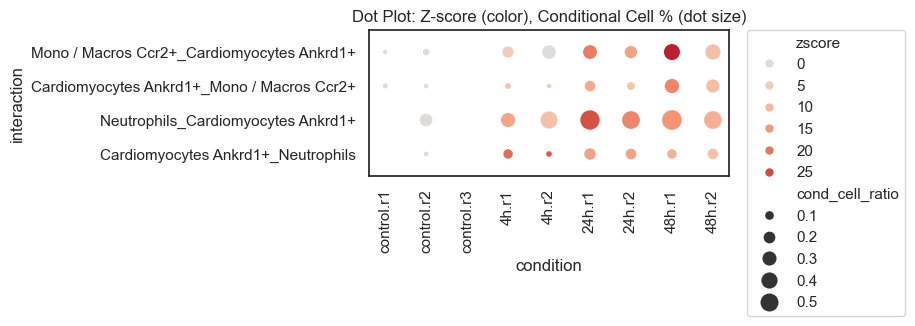

In [14]:
plt.figure(figsize=(9.5, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-30, 30),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_ankrd+_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [16]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_rad50_CM.xlsx', index=False)

In [18]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Endocardial cells',
    'Endocardial cells_Mono / Macros Ccr2+',
    'Neutrophils_Endocardial cells',
    'Endocardial cells_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [19]:
df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)


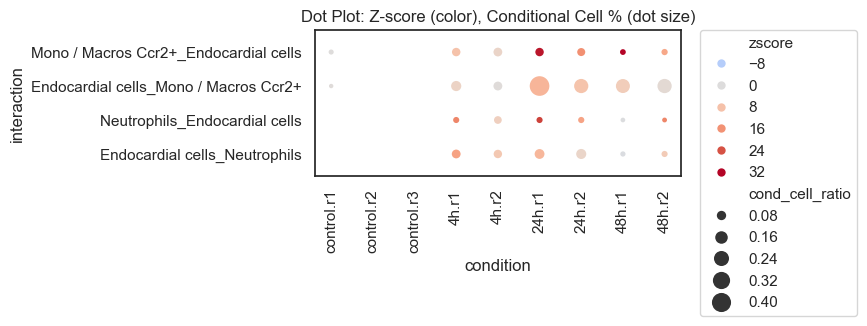

In [20]:
plt.figure(figsize=(9, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-30, 30),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_Endocard_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [21]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_rad50_endocard.xlsx', index=False)

# knn15

In [29]:
label = 'COZI_knn15'

df = adata.uns[label].copy()
df['phenotype'] = df['phenotype'].astype(str)
df['neighbour_phenotype'] = df['neighbour_phenotype'].astype(str)

# Create interaction label
df['interaction'] = df['phenotype'] + "_" + df['neighbour_phenotype']

# Melt the dataframe into long format
df_melted = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract type of metric and condition
df_melted['metric_type'] = df_melted['metric'].str.extract(r'^(zscore|cond_cell_ratio)')
df_melted['condition'] = df_melted['metric'].str.replace(r'^(zscore|cond_cell_ratio)_', '', regex=True)

# Pivot so we get one row per (interaction, condition) with both zscore and cond_cells
df_pivot = df_melted.pivot_table(index=['interaction', 'condition'], 
                                 columns='metric_type', 
                                 values='value').reset_index()

df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').astype(float)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').astype(float)


df_pivot

metric_type,interaction,condition,cond_cell_ratio,zscore
0,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_83,0.333194,-198.213389
1,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_86,0.743656,-307.571807
2,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_76,0.252123,-137.962970
3,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_79,0.239841,-150.136888
4,Cardiomyocytes Ankrd1+_Cardiomyocytes,4h_96,0.874875,-269.572582
...,...,...,...,...
1002,Smooth muscle cells_Smooth muscle cells,4h_96,0.827536,94.003892
1003,Smooth muscle cells_Smooth muscle cells,4h_97,0.854337,106.945227
1004,Smooth muscle cells_Smooth muscle cells,Control_12,0.766082,34.545794
1005,Smooth muscle cells_Smooth muscle cells,Control_13,0.783088,65.940897


In [30]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Mono / Macros Ccr2+',
    'Neutrophils_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/3744831338.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/3744831338.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [31]:
df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)

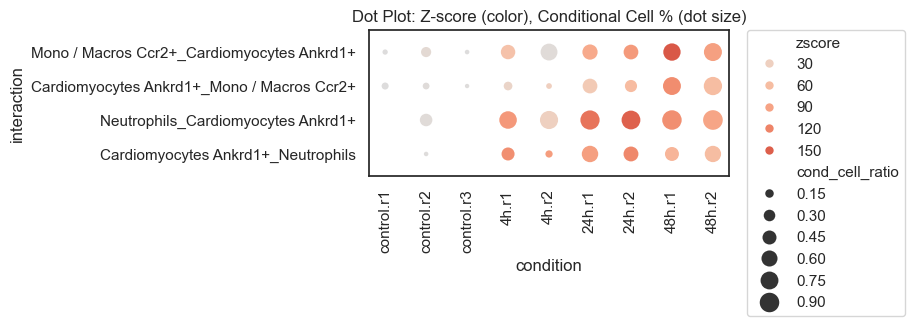

In [36]:
plt.figure(figsize=(9.5, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-200, 200),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_ankrd+_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [38]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_knn15_CM.xlsx', index=False)

In [39]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Endocardial cells',
    'Endocardial cells_Mono / Macros Ccr2+',
    'Neutrophils_Endocardial cells',
    'Endocardial cells_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [40]:
df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)

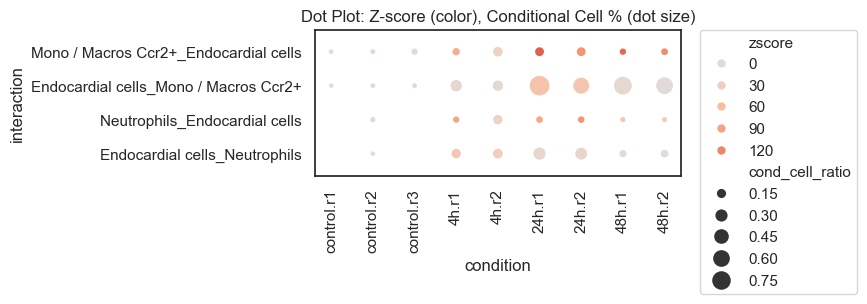

In [42]:
plt.figure(figsize=(9, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-200, 200),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_Endocard_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [43]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_knn15_endocard.xlsx', index=False)

# knn30

In [44]:
label = 'COZI_knn30'

df = adata.uns[label].copy()
df['phenotype'] = df['phenotype'].astype(str)
df['neighbour_phenotype'] = df['neighbour_phenotype'].astype(str)

# Create interaction label
df['interaction'] = df['phenotype'] + "_" + df['neighbour_phenotype']

# Melt the dataframe into long format
df_melted = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract type of metric and condition
df_melted['metric_type'] = df_melted['metric'].str.extract(r'^(zscore|cond_cell_ratio)')
df_melted['condition'] = df_melted['metric'].str.replace(r'^(zscore|cond_cell_ratio)_', '', regex=True)

# Pivot so we get one row per (interaction, condition) with both zscore and cond_cells
df_pivot = df_melted.pivot_table(index=['interaction', 'condition'], 
                                 columns='metric_type', 
                                 values='value').reset_index()

df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').astype(float)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').astype(float)


df_pivot

metric_type,interaction,condition,cond_cell_ratio,zscore
0,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_83,0.476031,-347.978013
1,Cardiomyocytes Ankrd1+_Cardiomyocytes,24h_86,0.878496,-424.585860
2,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_76,0.391178,-249.462055
3,Cardiomyocytes Ankrd1+_Cardiomyocytes,48h_79,0.358355,-262.757963
4,Cardiomyocytes Ankrd1+_Cardiomyocytes,4h_96,0.968380,-413.913920
...,...,...,...,...
1002,Smooth muscle cells_Smooth muscle cells,4h_96,0.859420,134.561495
1003,Smooth muscle cells_Smooth muscle cells,4h_97,0.882979,152.983356
1004,Smooth muscle cells_Smooth muscle cells,Control_12,0.798246,53.415124
1005,Smooth muscle cells_Smooth muscle cells,Control_13,0.840993,95.663662


In [45]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Mono / Macros Ccr2+',
    'Neutrophils_Cardiomyocytes Ankrd1+',
    'Cardiomyocytes Ankrd1+_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")
df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/2084014382.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/2084014382.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



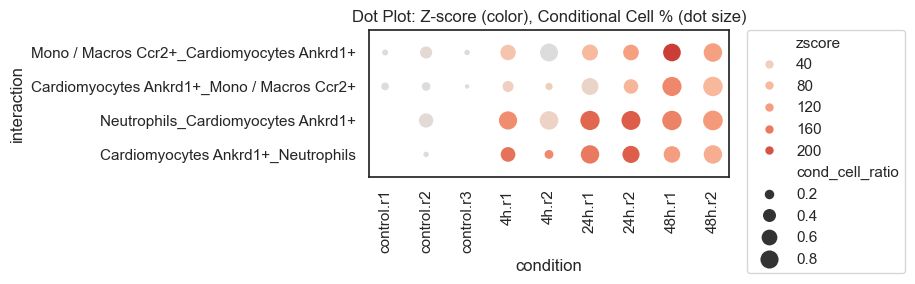

In [47]:
plt.figure(figsize=(9.5, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-250, 250),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_ankrd+_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [48]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_knn30_CM.xlsx', index=False)

In [49]:
interactions_of_interest = [
    'Mono / Macros Ccr2+_Endocardial cells',
    'Endocardial cells_Mono / Macros Ccr2+',
    'Neutrophils_Endocardial cells',
    'Endocardial cells_Neutrophils',
]

# Filter df_pivot
df_pivot_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)]


# Set categorical order for 'condition'
df_pivot_filtered['condition'] = pd.Categorical(
    df_pivot_filtered['condition'], categories=condition_order, ordered=True
)

df_pivot_filtered["interaction"] = pd.Categorical(
    df_pivot_filtered["interaction"],
    categories=interactions_of_interest,
    ordered=True
)

# Sort dataframe based on the new order
df_pivot_filtered = df_pivot_filtered.sort_values("interaction")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_71974/1913912509.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [50]:
df_pivot_filtered['condition'] = df_pivot_filtered['condition'].replace(condition_rename_map)

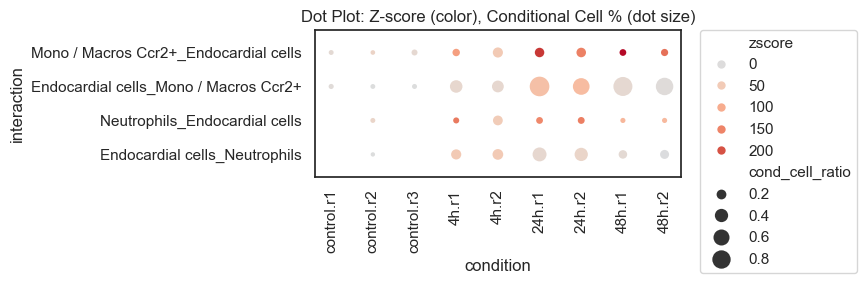

In [51]:
plt.figure(figsize=(9, 3))
sns.set(style='white')

# Dot plot: size = cond_cells_percentage, color = zscore
plot = sns.scatterplot(data=df_pivot_filtered,
                       x='condition', y='interaction',
                       size='cond_cell_ratio',
                       hue='zscore',
                       sizes=(10, 200),
                       palette='coolwarm',
                       edgecolor='gray',
                       hue_norm=(-250, 250),
                       linewidth=0)

# Show vertical grid lines only
#plot.grid(axis='y', linestyle='--', linewidth=0.5, color='gray')
plot.grid(axis='x', which='major', linestyle='', linewidth=0)  # disables y grid explicitly
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)
# Improve legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

#plt.savefig(f"./../../../../../Paper_figures/202506_dotplots/MI_immune_Endocard_rad50.svg", format="svg", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()


In [52]:
# save df_pivot_filtered as excel
df_pivot_filtered.to_excel('./../../../../../data/Source_data/Source_12_knn30_endocard.xlsx', index=False)